# Final Project — Data Mining & Data Visualization

**Oren Turiel │ Uri Lubetzki │ Noam Frei (314669508)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError(
        "xgboost is required for visitor_type imputation. "
        "Install it with: pip install xgboost"
    )

try:
    from catboost import CatBoostClassifier
except ImportError:
    raise ImportError(
        "catboost is required for month imputation. "
        "Install it with: pip install catboost"
    )

%matplotlib inline
try:
    sns.set_theme(style="whitegrid", palette="muted")
except AttributeError:
    sns.set(style="whitegrid", palette="muted")

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

TRAIN_PATH = "shopper_train.csv"
TEST_PATH  = "shopper_test.csv"

# Feature groups used throughout the pipeline
CATEGORICAL_COLS = ['month', 'visitor_type', 'operating_system', 'browser', 'region', 'traffic_type']
LOG_COLS         = ['admin_duration', 'info_duration', 'product_duration', 'page_value']
SCALE_COLS       = [
    'num_admin_pages', 'num_info_pages',
    'admin_duration', 'info_duration', 'product_duration',
    'page_value', 'exit_rate', 'abandonment_score',
    'engagement_score', 'special_day_score',
]

## Section 1 — Data Loading

We load the training dataset and confirm its dimensions.

In [2]:
df = pd.read_csv(TRAIN_PATH)
print(f"Training set shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns:\n{df.columns.tolist()}")

Training set shape: 9864 rows x 20 columns

Columns:
['num_admin_pages', 'admin_duration', 'num_info_pages', 'info_duration', 'num_product_pages', 'product_duration', 'bounce_rate', 'exit_rate', 'page_value', 'special_day_score', 'month', 'operating_system', 'browser', 'region', 'traffic_type', 'visitor_type', 'is_weekend', 'engagement_score', 'abandonment_score', 'high_intent']


## Section 2 — Dataset Overview

Each row is one user session. We inspect types, sample values, and basic statistics.

In [3]:
df.head()

,num_admin_pages,admin_duration,num_info_pages,info_duration,num_product_pages,product_duration,bounce_rate,exit_rate,page_value,special_day_score,month,operating_system,browser,region,traffic_type,visitor_type,is_weekend,engagement_score,abandonment_score,high_intent
0,0,0.0,0,0.0,3,13.000000,0.066667,0.133333,0.000000,0.0,NaN,3,2,3,3,Returning_Visitor,0,2.255623,0.100000,0
1,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,NaN,2,2,3,6,Returning_Visitor,0,0.400000,0.200000,0
2,0,0.0,0,0.0,8,101.750000,0.025000,0.075000,0.000000,0.0,Nov,2,2,6,2,NaN,0,5.052920,0.050000,0
3,0,0.0,2,38.2,121,3362.749679,0.025171,0.042322,4.212416,0.0,Jul,1,1,1,3,Returning_Visitor,0,52.048325,0.033747,1
4,2,2.0,0,0.0,0,NaN,0.100000,0.100000,0.000000,0.0,NaN,1,1,3,2,Returning_Visitor,1,0.000000,0.100000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   num_admin_pages    9864 non-null   int64  
 1   admin_duration     9864 non-null   float64
 2   num_info_pages     9864 non-null   int64  
 3   info_duration      9864 non-null   float64
 4   num_product_pages  9864 non-null   int64  
 5   product_duration   9466 non-null   float64
 6   bounce_rate        8707 non-null   float64
 7   exit_rate          9864 non-null   float64
 8   page_value         9368 non-null   float64
 9   special_day_score  9864 non-null   float64
 10  month              8404 non-null   object 
 11  operating_system   9864 non-null   int64  
 12  browser            9864 non-null   int64  
 13  region             9864 non-null   int64  
 14  traffic_type       9864 non-null   int64  
 15  visitor_type       8868 non-null   object 
 16  is_weekend         9864 

In [5]:
col_meta = pd.DataFrame({
    'Data Type'     : df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2),
    'Unique Values' : df.nunique(),
})
display(col_meta)

,Data Type,Missing Values,Missing %,Unique Values
num_admin_pages,int64,0,0.00,26
admin_duration,float64,0,0.00,2805
num_info_pages,int64,0,0.00,16
info_duration,float64,0,0.00,1064
num_product_pages,int64,0,0.00,291
product_duration,float64,398,4.03,7480
bounce_rate,float64,1157,11.73,1466
exit_rate,float64,0,0.00,3974
page_value,float64,496,5.03,2082
special_day_score,float64,0,0.00,6


In [6]:
# Exclude integer-coded nominals from descriptive statistics
EXCLUDE_FROM_STATS = ['operating_system', 'browser', 'region', 'traffic_type', 'is_weekend', 'high_intent']
num_cols = [c for c in df.select_dtypes(include='number').columns if c not in EXCLUDE_FROM_STATS]
display(df[num_cols].describe().T.round(4))

,count,mean,std,min,25%,50%,75%,max
num_admin_pages,9864.0,2.3160,3.3178,0.0,0.0000,1.0000,4.0000,27.0000
admin_duration,9864.0,80.6495,176.6616,0.0,0.0000,7.0000,94.0000,3398.7500
num_info_pages,9864.0,0.5053,1.2801,0.0,0.0000,0.0000,0.0000,24.0000
info_duration,9864.0,34.8506,143.0302,0.0,0.0000,0.0000,0.0000,2549.3750
num_product_pages,9864.0,31.9672,45.2119,0.0,7.0000,18.0000,38.0000,705.0000
product_duration,9466.0,1210.7741,1995.7962,0.0,181.0000,601.7792,1475.9182,63973.5222
bounce_rate,8707.0,0.0227,0.0493,0.0,0.0000,0.0032,0.0171,0.2000
exit_rate,9864.0,0.0434,0.0490,0.0,0.0143,0.0253,0.0500,0.2000
page_value,9368.0,5.9088,18.3766,0.0,0.0000,0.0000,0.0000,361.7637
special_day_score,9864.0,0.0612,0.1985,0.0,0.0000,0.0000,0.0000,1.0000


## Section 3 — Data Quality Assessment

We audit missing values at both the column and row level before deciding on imputation strategies.

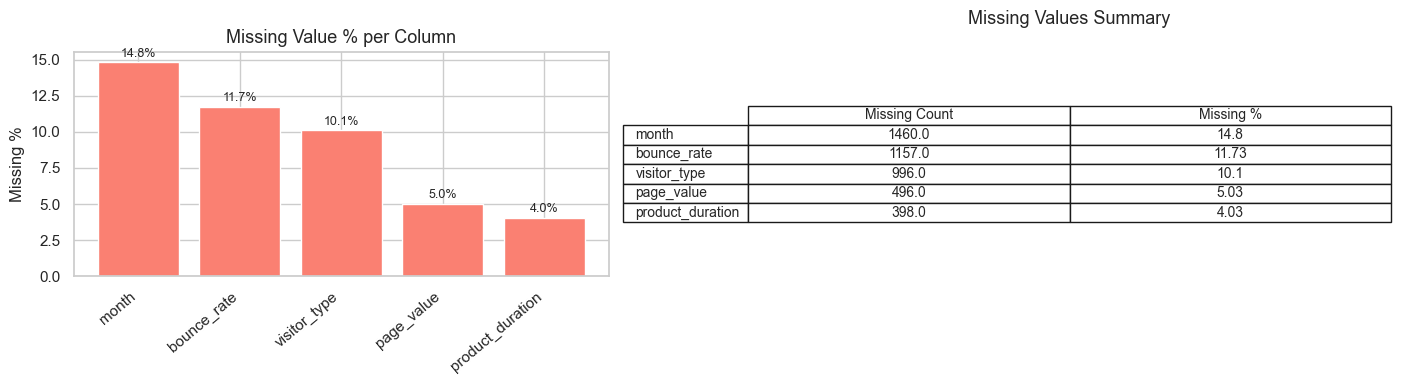

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars = axes[0].bar(missing.index, missing_pct.values, color='salmon')
axes[0].set_title('Missing Value % per Column', fontsize=13)
axes[0].set_ylabel('Missing %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')
for bar, val in zip(bars, missing_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

summary_tbl = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
axes[1].axis('off')
tbl = axes[1].table(
    cellText=summary_tbl.values.tolist(),
    rowLabels=summary_tbl.index.tolist(),
    colLabels=summary_tbl.columns.tolist(),
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
axes[1].set_title('Missing Values Summary', pad=20, fontsize=13)

plt.tight_layout()
plt.show()

In [8]:
missing_per_row = df.isnull().sum(axis=1)
row_summary = missing_per_row.value_counts().sort_index().reset_index()
row_summary.columns = ['Missing Values in Row', 'Row Count']
display(row_summary)

rows_with_missing = (missing_per_row > 0).sum()
print(f"\nRows with at least 1 missing value: {rows_with_missing} "
      f"({rows_with_missing / len(df) * 100:.1f}%)")

,Missing Values in Row,Row Count
0,0,6056
1,1,3153
2,2,611
3,3,44



Rows with at least 1 missing value: 3808 (38.6%)


## Section 4 — Univariate Analysis

We examine the distribution of each feature individually.

### 4.1 Numeric Features — Skewness

In [9]:
skew_df = (
    df[num_cols].skew()
    .reset_index()
    .rename(columns={'index': 'Feature', 0: 'Skewness'})
    .sort_values('Skewness', ascending=False)
    .reset_index(drop=True)
)
display(skew_df)
print("\nFeatures with |skewness| > 1 are candidates for log transformation.")

,Feature,Skewness
0,product_duration,7.755150
1,info_duration,7.599689
2,page_value,6.313180
3,admin_duration,5.743064
4,num_product_pages,4.266238
5,num_info_pages,4.159568
6,engagement_score,4.084522
7,special_day_score,3.311363
8,bounce_rate,2.892041
9,abandonment_score,2.632243



Features with |skewness| > 1 are candidates for log transformation.


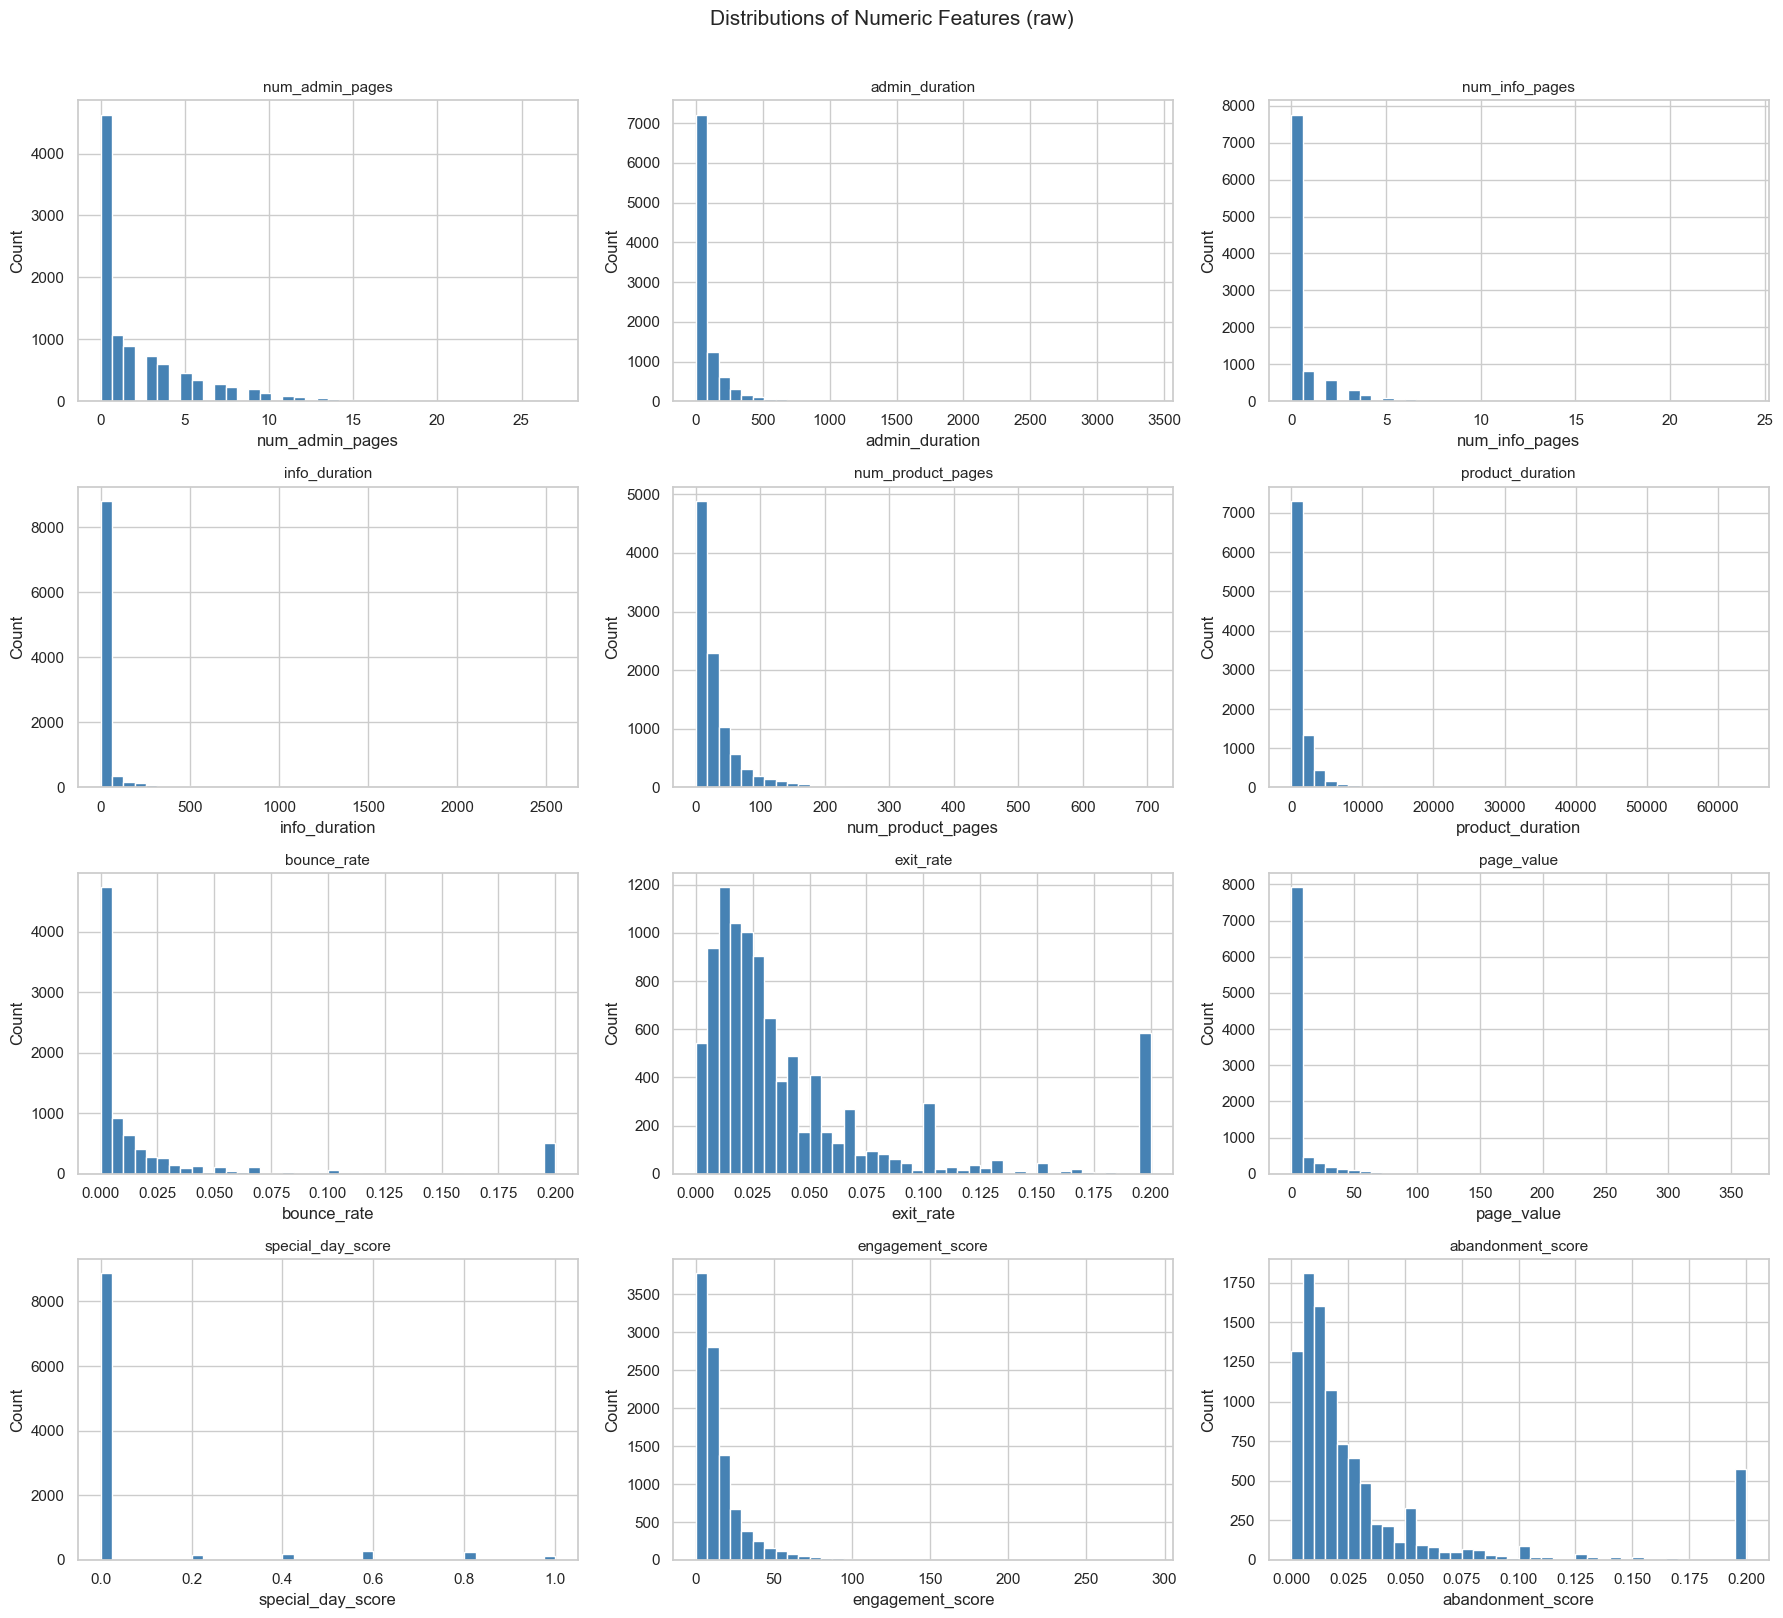

In [10]:
n = len(num_cols)
n_cols_fig = 3
n_rows_fig = int(np.ceil(n / n_cols_fig))

fig, axes = plt.subplots(n_rows_fig, n_cols_fig, figsize=(18, n_rows_fig * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of Numeric Features (raw)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

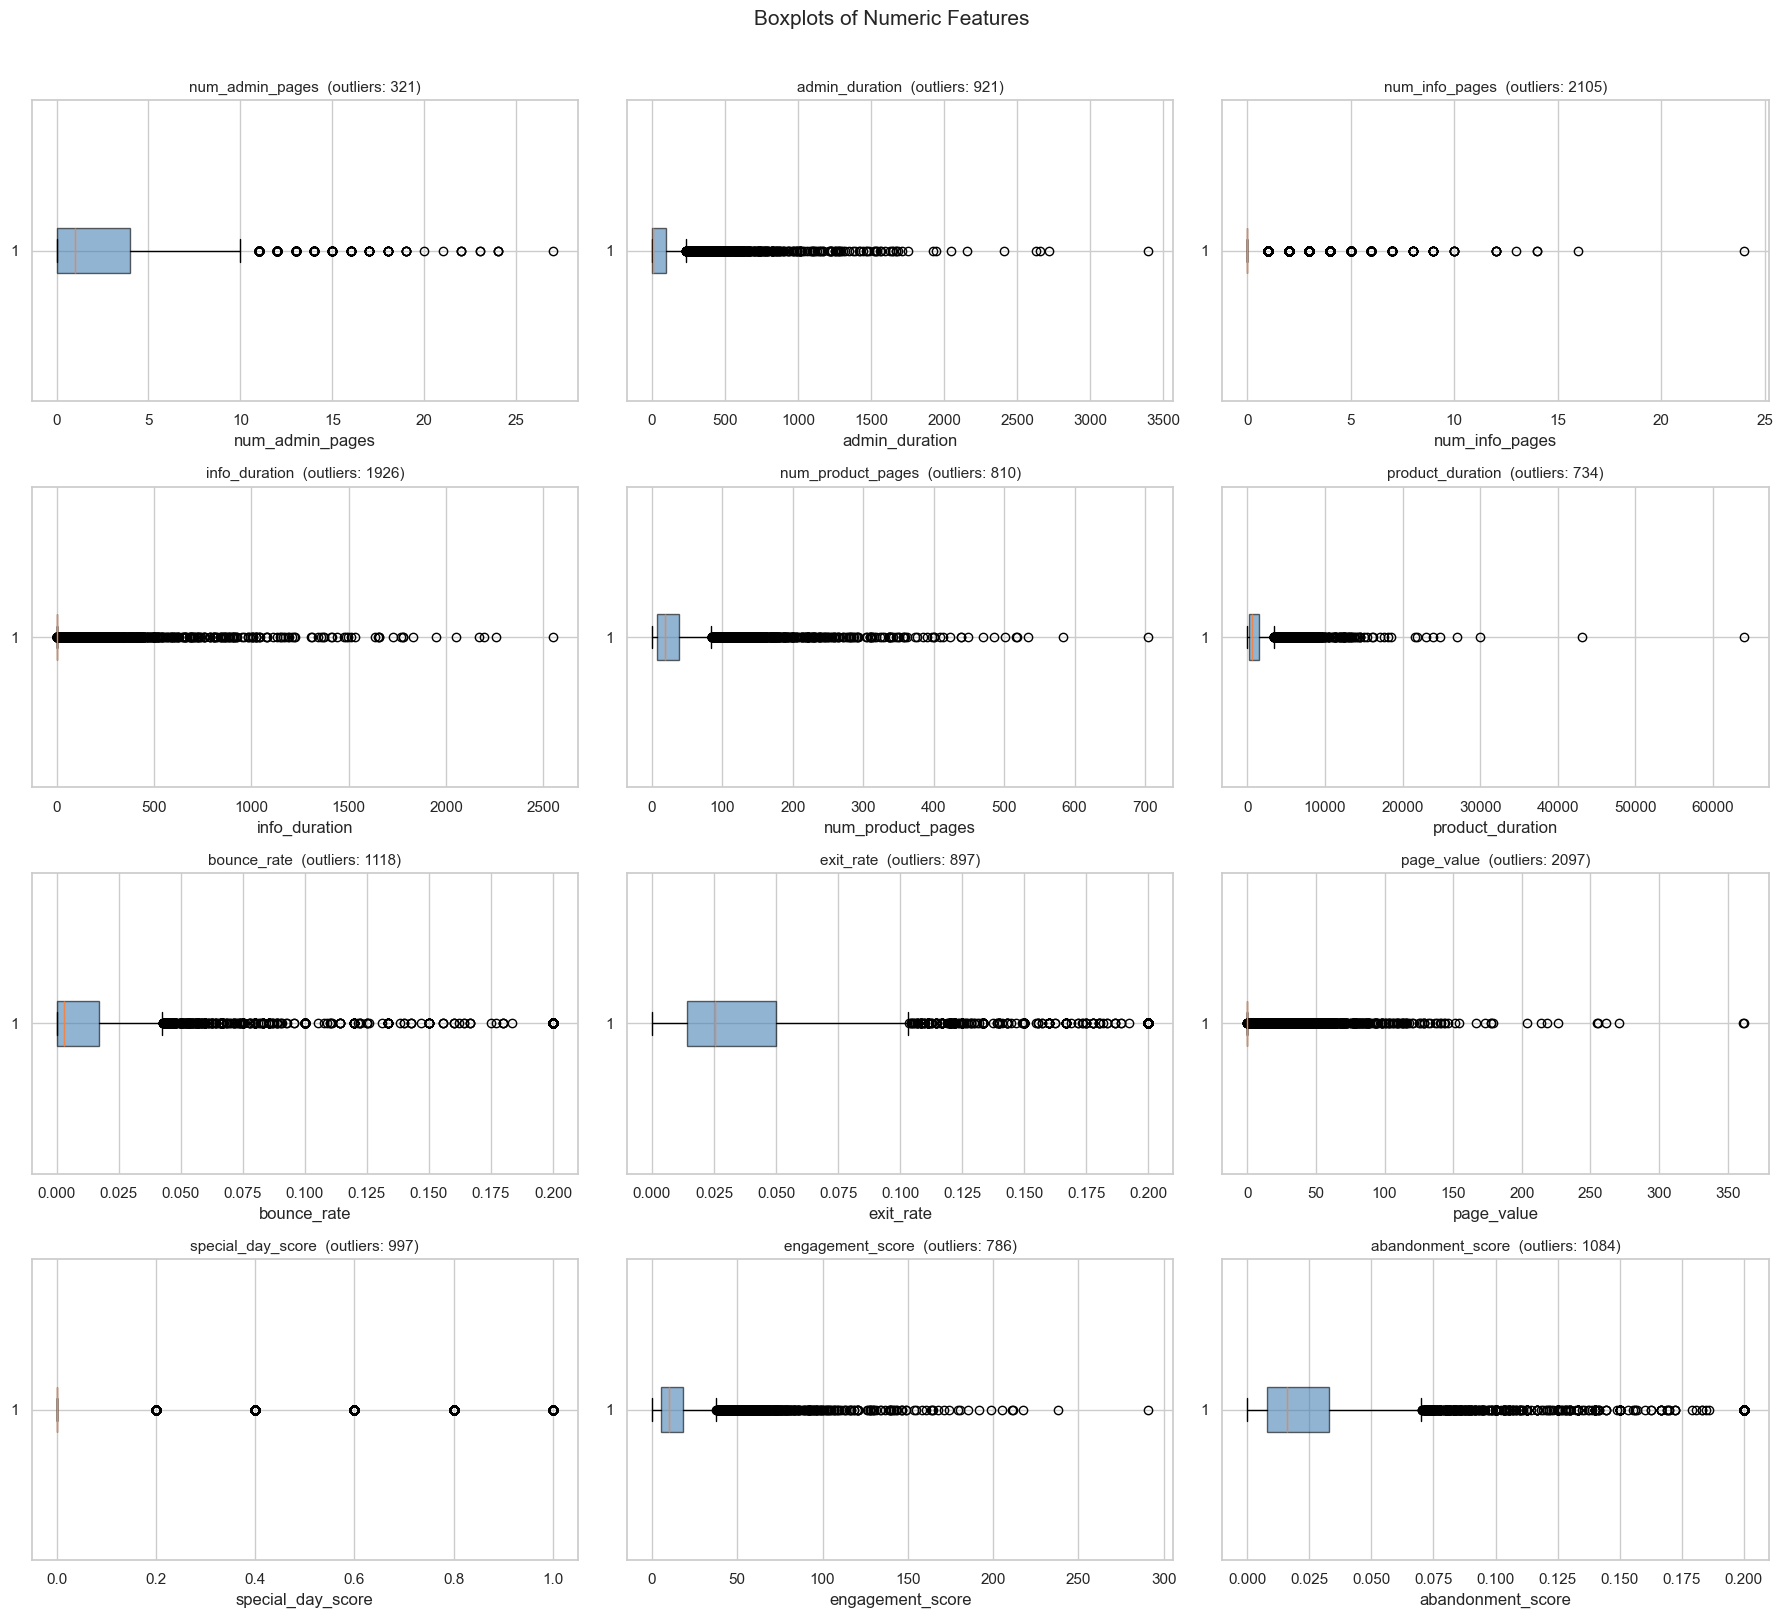

In [11]:
fig, axes = plt.subplots(n_rows_fig, n_cols_fig, figsize=(18, n_rows_fig * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}  (outliers: {n_outliers})', fontsize=11)
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of Numeric Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Categorical Features

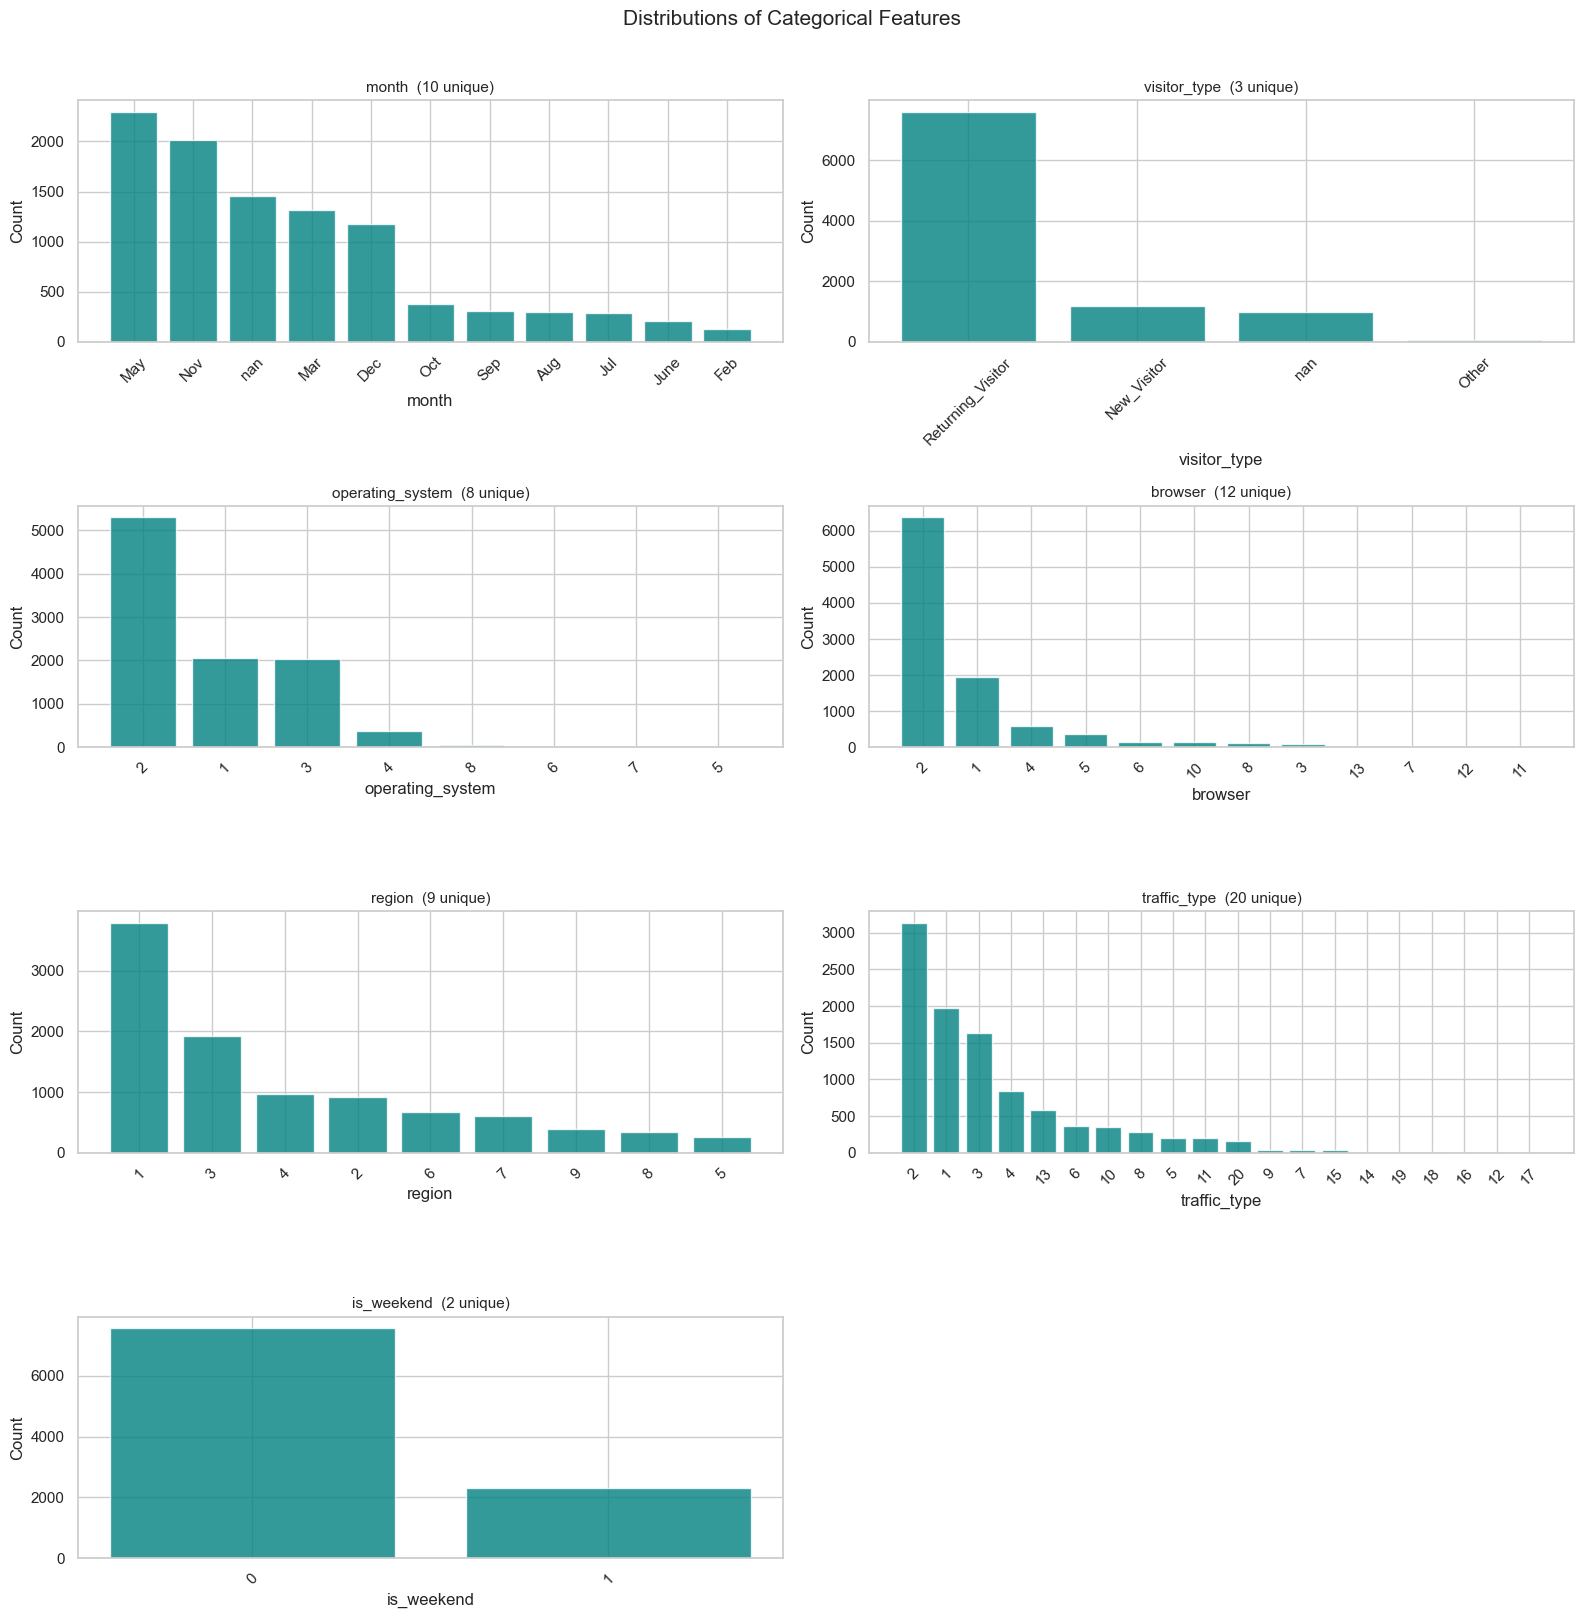

In [12]:
cat_cols_plot = ['month', 'visitor_type', 'operating_system', 'browser', 'region', 'traffic_type', 'is_weekend']

n_cat = len(cat_cols_plot)
n_cat_cols = 2
n_cat_rows = int(np.ceil(n_cat / n_cat_cols))

fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(16, n_cat_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    counts = df[col].value_counts(dropna=False)
    axes[i].bar(counts.index.astype(str), counts.values, color='teal', alpha=0.8)
    axes[i].set_title(f'{col}  ({df[col].nunique(dropna=True)} unique)', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of Categorical Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Target Variable Distribution

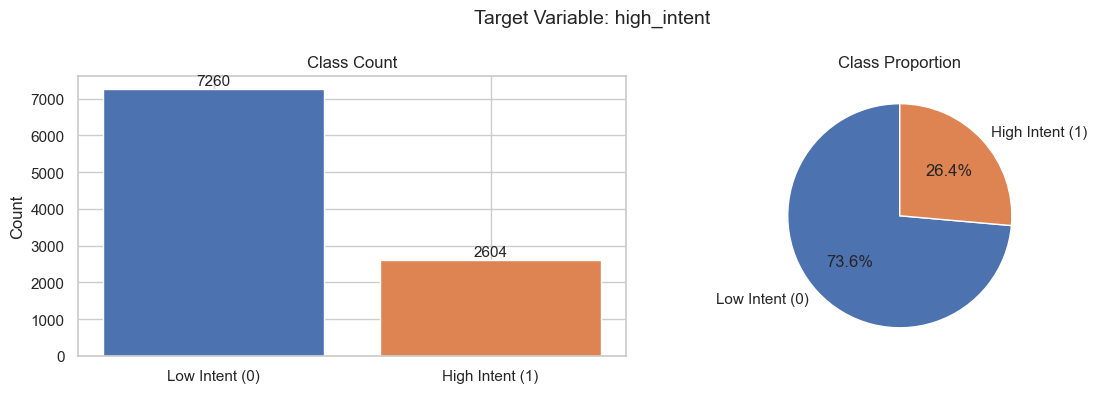

Class balance: 2604/9864 = 26.4% high-intent sessions
Note: moderate imbalance; accuracy alone is a misleading metric for this problem.


In [13]:
target_counts = df['high_intent'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Low Intent (0)', 'High Intent (1)'], target_counts.values,
            color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Count')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontsize=11)

axes[1].pie(target_counts, labels=['Low Intent (0)', 'High Intent (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable: high_intent', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Class balance: {target_counts[1]}/{len(df)} = {target_counts[1]/len(df)*100:.1f}% high-intent sessions")
print("Note: moderate imbalance; accuracy alone is a misleading metric for this problem.")

## Section 5 — Bivariate Analysis & Non-trivial Insights

We explore relationships between features and the target, and between features themselves, to surface actionable patterns.

### Insight 1: Strong Seasonal Pattern in Purchase Intent

High-intent sessions are not uniformly distributed across months. This suggests that time-of-year is a meaningful contextual signal.

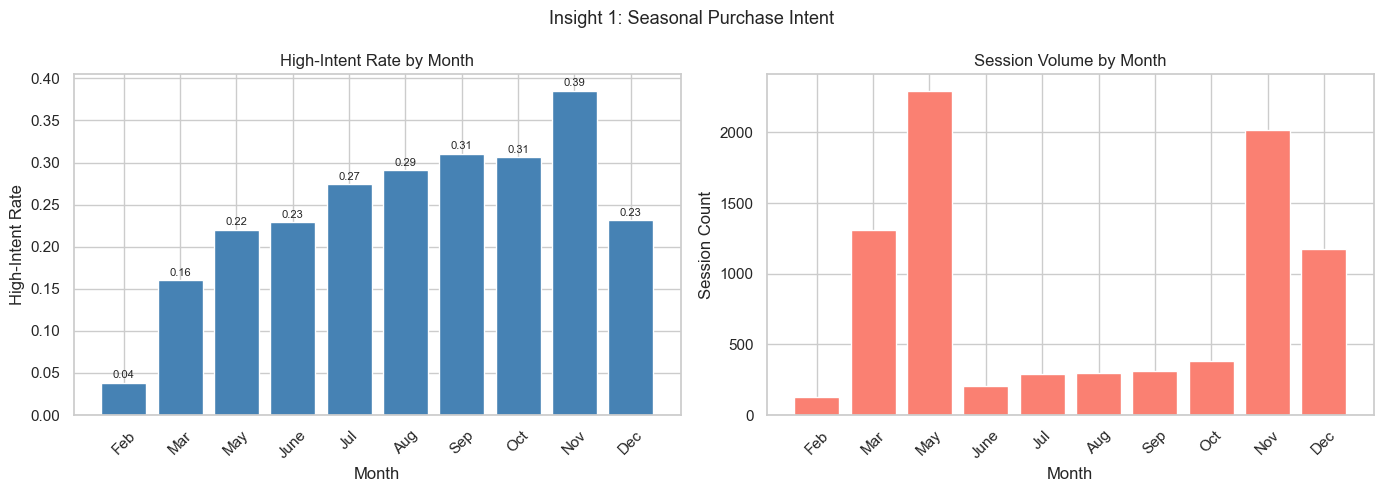

,High-Intent Rate,Sessions
month,,
Feb,0.038462,130
Mar,0.159939,1313
May,0.219948,2296
June,0.229268,205
Jul,0.274306,288
Aug,0.290541,296
Sep,0.310680,309
Oct,0.306069,379
Nov,0.385417,2016


In [14]:
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
present_months = [m for m in MONTH_ORDER if m in df['month'].dropna().unique()]

month_stats = (
    df.dropna(subset=['month'])
    .groupby('month')['high_intent']
    .agg(rate='mean', count='count')
    .reindex(present_months)
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(month_stats.index, month_stats['rate'], color='steelblue')
axes[0].set_title('High-Intent Rate by Month', fontsize=12)
axes[0].set_ylabel('High-Intent Rate')
axes[0].set_xlabel('Month')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, month_stats['rate']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)

axes[1].bar(month_stats.index, month_stats['count'], color='salmon')
axes[1].set_title('Session Volume by Month', fontsize=12)
axes[1].set_ylabel('Session Count')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Insight 1: Seasonal Purchase Intent', fontsize=13)
plt.tight_layout()
plt.show()
display(month_stats.rename(columns={'rate': 'High-Intent Rate', 'count': 'Sessions'}))

### Insight 2: page_value Is the Strongest Intent Discriminator

`page_value` reflects the commercial value of pages viewed. High-intent sessions are concentrated at non-zero page values, while low-intent sessions are almost entirely at zero. This makes it the single most predictive feature.

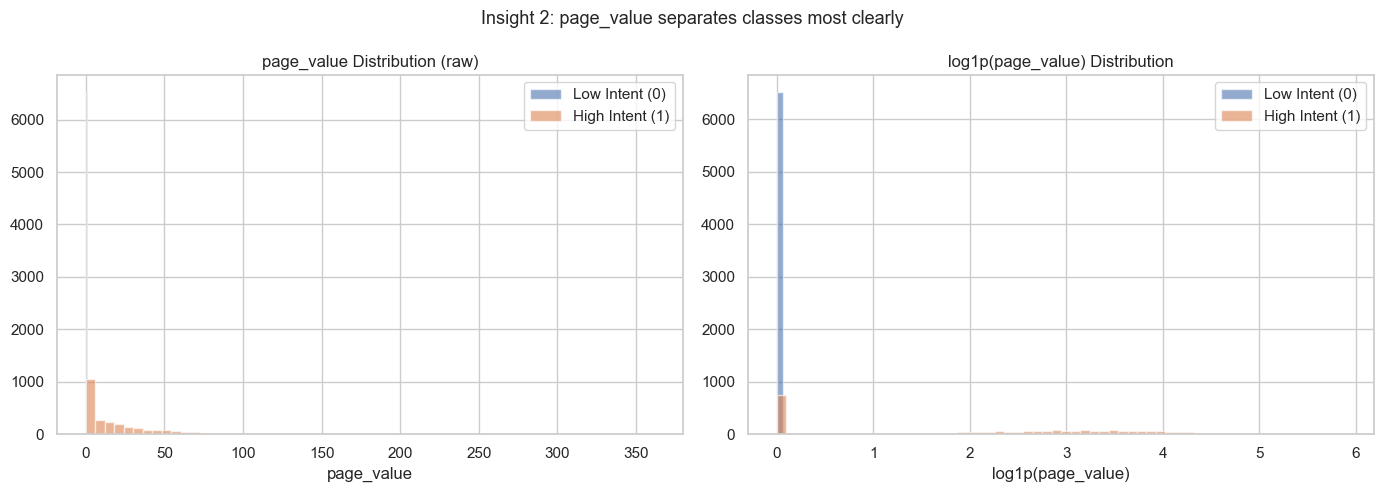

,mean,median,std
high_intent,,,
Low Intent,0.510583,0.000000,2.701099
High Intent,20.967906,10.064683,30.847886


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {0: '#4C72B0', 1: '#DD8452'}
labels = {0: 'Low Intent (0)', 1: 'High Intent (1)'}

for label in [0, 1]:
    vals = df[df['high_intent'] == label]['page_value'].dropna()
    axes[0].hist(vals, bins=60, alpha=0.6, color=colors[label], label=labels[label])
axes[0].set_title('page_value Distribution (raw)')
axes[0].set_xlabel('page_value')
axes[0].legend()

for label in [0, 1]:
    vals = np.log1p(df[df['high_intent'] == label]['page_value'].dropna())
    axes[1].hist(vals, bins=60, alpha=0.6, color=colors[label], label=labels[label])
axes[1].set_title('log1p(page_value) Distribution')
axes[1].set_xlabel('log1p(page_value)')
axes[1].legend()

plt.suptitle('Insight 2: page_value separates classes most clearly', fontsize=13)
plt.tight_layout()
plt.show()

display(df.groupby('high_intent')['page_value']
        .agg(['mean', 'median', 'std'])
        .rename(index={0: 'Low Intent', 1: 'High Intent'}))

### Insight 3: High-Intent Sessions Show Deeper Product Browsing

Sessions classified as high-intent spend significantly more time on product pages and have higher engagement scores. The separation is clear after a log transformation.

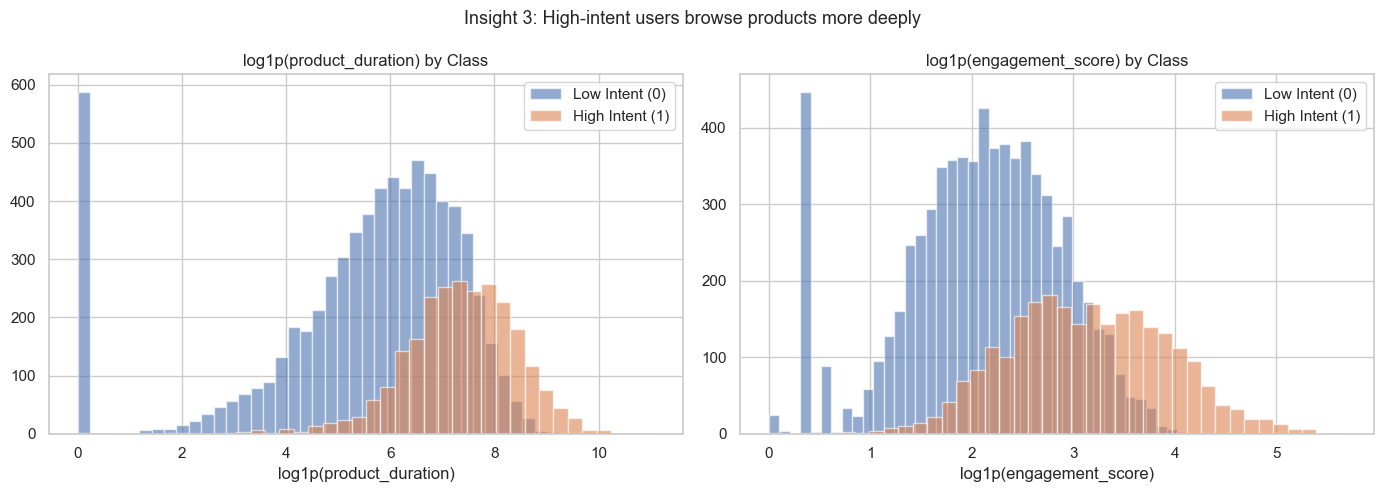

,product_duration,engagement_score
high_intent,,
Low Intent,714.09,9.71
High Intent,2596.25,30.77


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in [0, 1]:
    vals = np.log1p(df[df['high_intent'] == label]['product_duration'].dropna())
    axes[0].hist(vals, bins=40, alpha=0.6, color=colors[label], label=labels[label])
axes[0].set_title('log1p(product_duration) by Class')
axes[0].set_xlabel('log1p(product_duration)')
axes[0].legend()

for label in [0, 1]:
    vals = np.log1p(df[df['high_intent'] == label]['engagement_score'].dropna())
    axes[1].hist(vals, bins=40, alpha=0.6, color=colors[label], label=labels[label])
axes[1].set_title('log1p(engagement_score) by Class')
axes[1].set_xlabel('log1p(engagement_score)')
axes[1].legend()

plt.suptitle('Insight 3: High-intent users browse products more deeply', fontsize=13)
plt.tight_layout()
plt.show()

display(df.groupby('high_intent')[['product_duration', 'engagement_score']]
        .mean().round(2)
        .rename(index={0: 'Low Intent', 1: 'High Intent'}))

### Insight 4: Returning Visitors Convert at a Higher Rate

New visitors explore the site without committing, whereas returning visitors already have intent formed from previous sessions.

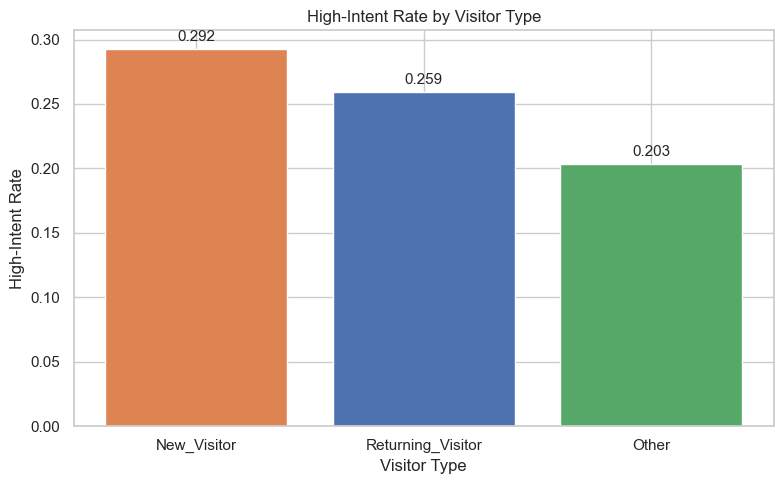

,High-Intent Rate,Sessions
visitor_type,,
New_Visitor,0.29250,1200
Returning_Visitor,0.25943,7609
Other,0.20339,59


In [17]:
vt_stats = (
    df.dropna(subset=['visitor_type'])
    .groupby('visitor_type')['high_intent']
    .agg(rate='mean', count='count')
    .sort_values('rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(vt_stats.index, vt_stats['rate'], color=['#DD8452', '#4C72B0', '#55A868'])
ax.set_title('High-Intent Rate by Visitor Type', fontsize=12)
ax.set_ylabel('High-Intent Rate')
ax.set_xlabel('Visitor Type')
for bar, val in zip(bars, vt_stats['rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()
display(vt_stats.rename(columns={'rate': 'High-Intent Rate', 'count': 'Sessions'}))

### Insight 5: Proximity to Special Days Does Not Increase Intent

Contrary to marketing intuition, sessions occurring near special events (higher `special_day_score`) show *lower* conversion. A possible explanation: users browsing near holidays may be comparison-shopping rather than committing.

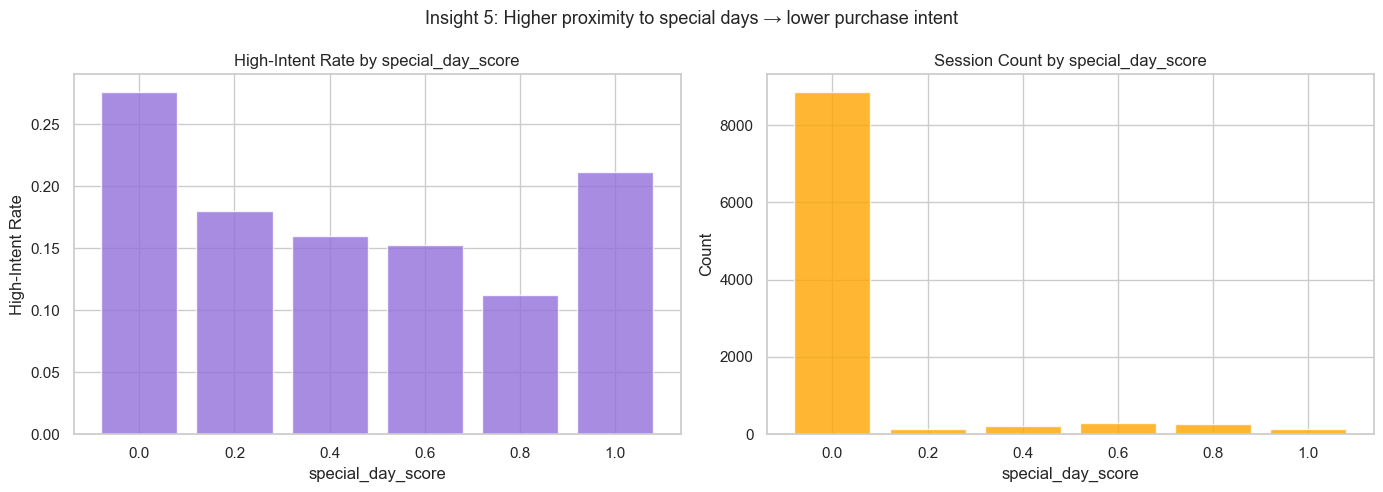

,High-Intent Rate,Sessions
special_day_score,,
0.0,0.276305,8867
0.2,0.179856,139
0.4,0.160000,200
0.6,0.152174,276
0.8,0.111969,259
1.0,0.211382,123


In [18]:
special_stats = (
    df.groupby('special_day_score')['high_intent']
    .agg(rate='mean', count='count')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(special_stats.index.astype(str), special_stats['rate'], color='mediumpurple', alpha=0.8)
axes[0].set_title('High-Intent Rate by special_day_score', fontsize=12)
axes[0].set_ylabel('High-Intent Rate')
axes[0].set_xlabel('special_day_score')

axes[1].bar(special_stats.index.astype(str), special_stats['count'], color='orange', alpha=0.8)
axes[1].set_title('Session Count by special_day_score', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('special_day_score')

plt.suptitle('Insight 5: Higher proximity to special days → lower purchase intent', fontsize=13)
plt.tight_layout()
plt.show()
display(special_stats.rename(columns={'rate': 'High-Intent Rate', 'count': 'Sessions'}))

### Insight 6: Weekend vs. Weekday Intent (Statistical Test)

We use a chi-square test to determine whether the observed difference in conversion rates across weekend and weekday sessions is statistically significant.

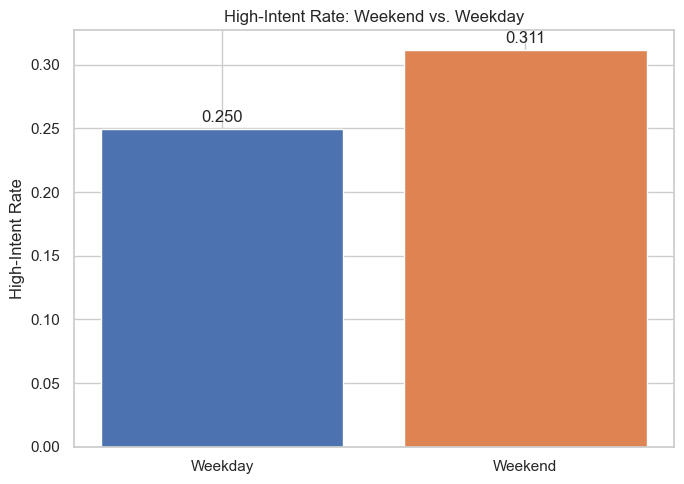

Chi-square: chi2 = 34.4179,  dof = 1,  p-value = 0.0000
Result: Statistically significant (p < 0.05)


In [19]:
weekend_stats = (
    df.groupby('is_weekend')['high_intent']
    .agg(rate='mean', count='count')
)
weekend_stats.index = ['Weekday', 'Weekend']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(weekend_stats.index, weekend_stats['rate'], color=['#4C72B0', '#DD8452'])
ax.set_title('High-Intent Rate: Weekend vs. Weekday', fontsize=12)
ax.set_ylabel('High-Intent Rate')
for bar, val in zip(bars, weekend_stats['rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

ct = pd.crosstab(df['is_weekend'], df['high_intent'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"Chi-square: chi2 = {chi2:.4f},  dof = {dof},  p-value = {p:.4f}")
print("Result:", "Statistically significant (p < 0.05)" if p < 0.05 else "Not significant (p >= 0.05)")

## Section 6 — Correlation Analysis

We compute pairwise Pearson correlations for all numeric features to identify redundant columns and quantify feature-target relationships.

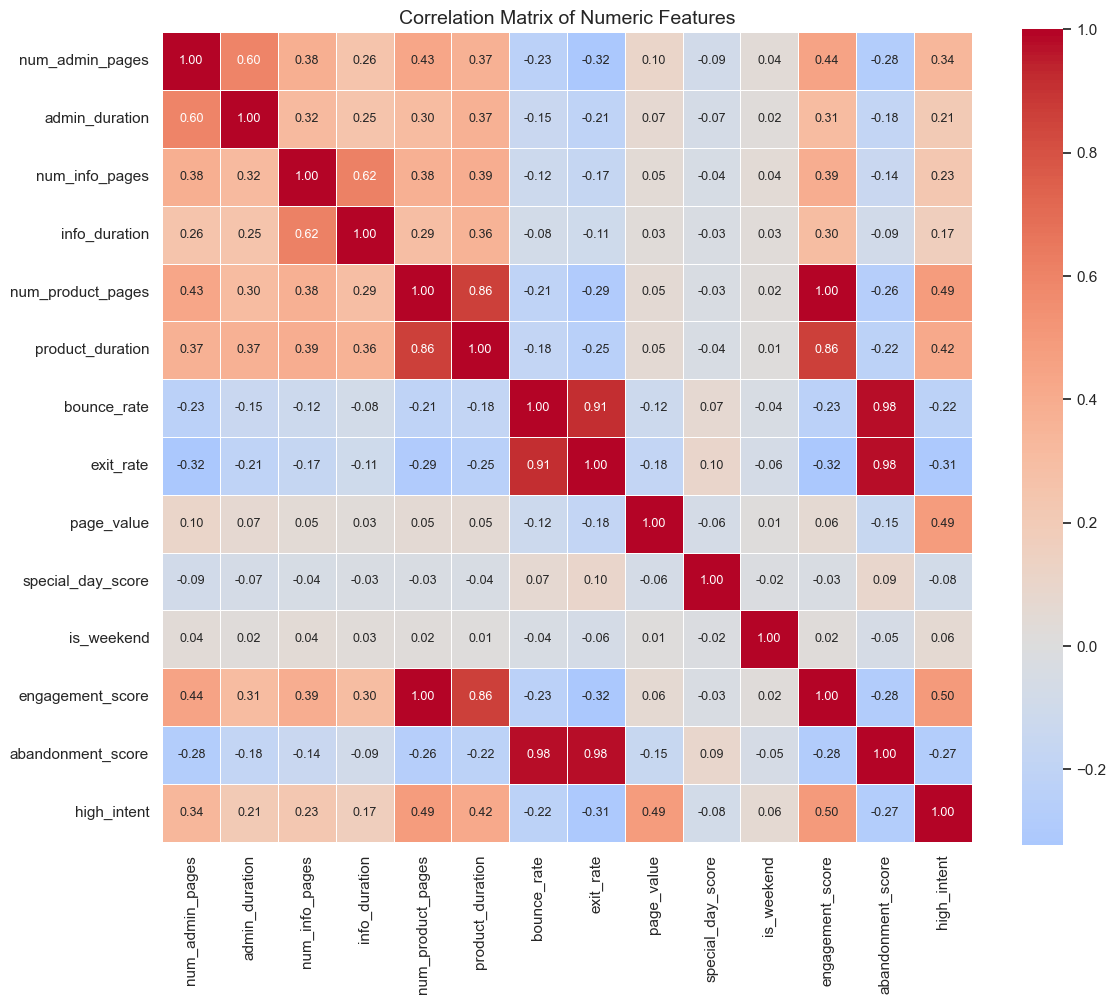

In [20]:
corr_exclude = ['operating_system', 'browser', 'region', 'traffic_type']
corr_cols = [c for c in df.select_dtypes(include='number').columns if c not in corr_exclude]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

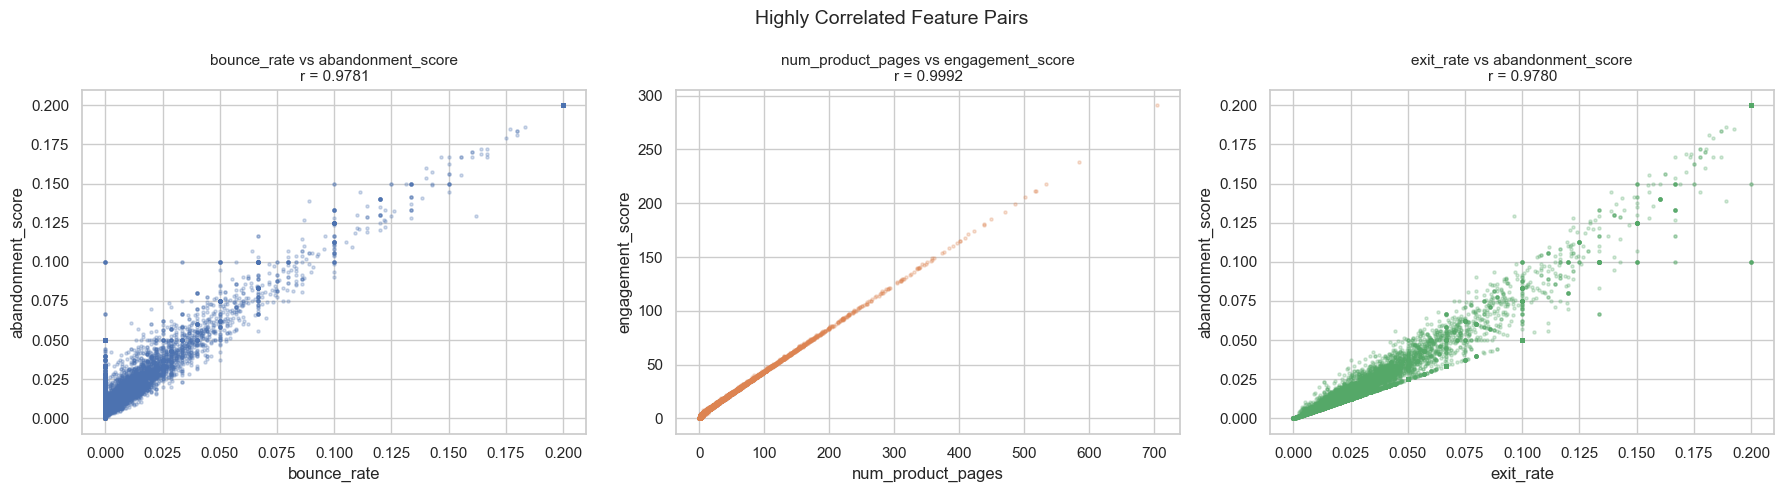

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('bounce_rate', 'abandonment_score', '#4C72B0'),
    ('num_product_pages', 'engagement_score', '#DD8452'),
    ('exit_rate', 'abandonment_score', '#55A868'),
]
for ax, (x, y, c) in zip(axes, pairs):
    r = df[[x, y]].corr().iloc[0, 1]
    ax.scatter(df[x], df[y], alpha=0.25, s=5, color=c)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nr = {r:.4f}', fontsize=11)

plt.suptitle('Highly Correlated Feature Pairs', fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Findings

| Pair | Correlation | Action |
|---|---|---|
| `bounce_rate` ↔ `abandonment_score` | r ≈ 0.98 | Drop `bounce_rate`: nearly identical signal, also has 11% missing values |
| `num_product_pages` ↔ `engagement_score` | r ≈ 1.00 | Drop `num_product_pages` after using it in imputation: perfect linear proxy |
| `exit_rate` ↔ `abandonment_score` | r ≈ 0.90 | Retain both: high but not perfect; distinct conceptual meaning |

We retain `abandonment_score` and `engagement_score` as the surviving representatives of each near-duplicate pair.

## Section 7 — Preprocessing

All transformations are learned from `shopper_train.csv` only. Learned parameters are stored in `pipeline_params` and reused on the test set in Section 8.

### Step 7.1 — Drop Highly Correlated Feature: `bounce_rate`

**Justification:** `bounce_rate` has r = 0.98 with `abandonment_score` (confirmed in Section 6) and 11% missing values — the highest of any column. Keeping it adds no independent signal and complicates imputation unnecessarily.

In [22]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=['bounce_rate'])
print(f"Dropped: bounce_rate")
print(f"Shape after drop: {df_clean.shape}")

Dropped: bounce_rate
Shape after drop: (9864, 19)


### Step 7.2 — Outlier Treatment: `engagement_score`

`engagement_score` has a long right tail with extreme values that would skew distance-based models. We clip at the 95th percentile to reduce their influence while preserving the bulk of the distribution.

95th percentile clip threshold: 48.1141
Values above threshold: 494


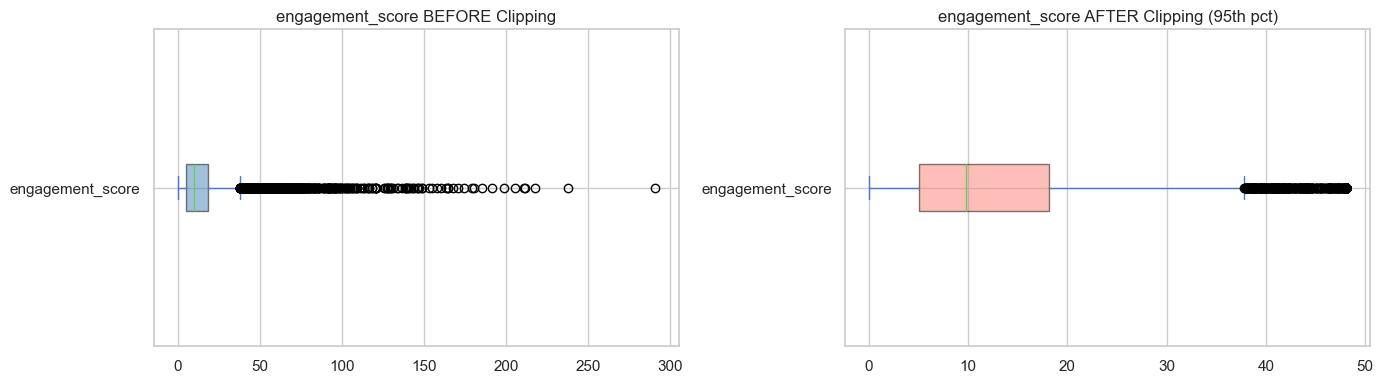

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean['engagement_score'].plot(kind='box', vert=False, ax=axes[0],
                                   patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[0].set_title('engagement_score BEFORE Clipping')

clip_threshold = df_clean['engagement_score'].quantile(0.95)
print(f"95th percentile clip threshold: {clip_threshold:.4f}")
print(f"Values above threshold: {(df_clean['engagement_score'] > clip_threshold).sum()}")
df_clean['engagement_score'] = df_clean['engagement_score'].clip(upper=clip_threshold)

df_clean['engagement_score'].plot(kind='box', vert=False, ax=axes[1],
                                   patch_artist=True, boxprops=dict(facecolor='salmon', alpha=0.5))
axes[1].set_title('engagement_score AFTER Clipping (95th pct)')
plt.tight_layout()
plt.show()

### Step 7.3 — Missing Value Imputation

Each feature with missing values receives an imputation strategy selected by a private benchmark against ground-truth values from the original dataset.

| Feature | Missing % | Strategy | Justification |
|---|---|---|---|
| `product_duration` (zero-fill) | ~4 % | Zero where `num_product_pages == 0` | No pages visited ⇒ zero time spent |
| `month` | ~14 % | **CatBoostClassifier** | Ranked #1 in benchmark (Accuracy = 0.4431); outperforms XGBoost and RandomForest |
| `visitor_type` | ~10 % | **XGBoostClassifier** | Ranked #1 in benchmark (best accuracy & F1); stronger than RandomForest on this feature |
| `product_duration` (remaining) | remaining | **HistGradientBoostingRegressor** (engagement_score) | Ranked #1 in benchmark (MAE = 314.6); log1p/expm1 applied to handle skewed target |
| `page_value` | ~5 % | **Conditional Median** (by `traffic_type`) | Lowest MAE in benchmark; robust to outliers; no label leakage |

**Key constraint:** `high_intent` (the target) is never used in any imputation step to prevent data leakage.

In [24]:
# 3a: Zero-fill product_duration where num_product_pages is 0
cond_zero = (df_clean['num_product_pages'] == 0) & df_clean['product_duration'].isna()
n_zero_filled = cond_zero.sum()
df_clean.loc[cond_zero, 'product_duration'] = 0.0
print(f"Zero-filled {n_zero_filled} rows in 'product_duration'")
print(f"Remaining missing in product_duration: {df_clean['product_duration'].isna().sum()}")

Zero-filled 3 rows in 'product_duration'
Remaining missing in product_duration: 395


In [ ]:
# 3b: Month — CatBoostClassifier imputation
# Benchmark result: CatBoost ranked #1 (Accuracy = 0.4431), outperforming XGBoost and RandomForest.
# CatBoost handles string labels natively — no LabelEncoder required.
# high_intent is NOT used — no label leakage.

XGB_MONTH_FEATURES = [
    'num_product_pages', 'exit_rate', 'admin_duration', 'info_duration',
    'special_day_score', 'is_weekend', 'operating_system', 'browser',
    'region', 'traffic_type', 'engagement_score', 'abandonment_score',
]

month_known   = df_clean[df_clean['month'].notna()].dropna(subset=XGB_MONTH_FEATURES)
month_missing = df_clean[df_clean['month'].isna()].dropna(subset=XGB_MONTH_FEATURES)
print(f"month — known: {len(month_known)}, "
      f"missing in train: {df_clean['month'].isna().sum()}")

catboost_month_imputer = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=RANDOM_SEED,
    verbose=False,
    allow_writing_files=False,
)
catboost_month_imputer.fit(month_known[XGB_MONTH_FEATURES], month_known['month'].astype(str))

if len(month_missing) > 0:
    preds = catboost_month_imputer.predict(month_missing[XGB_MONTH_FEATURES]).reshape(-1)
    df_clean.loc[month_missing.index, 'month'] = preds

# Fallback: mode for any rows where CatBoost features are also missing
month_mode = df_clean.loc[df_clean['month'].notna(), 'month'].mode()[0]
remaining = df_clean['month'].isna().sum()
if remaining > 0:
    df_clean['month'] = df_clean['month'].fillna(month_mode)
    print(f"Mode fallback applied to {remaining} row(s).")

print(f"Remaining missing in 'month': {df_clean['month'].isna().sum()}")

In [ ]:
# 3c: visitor_type — XGBoostClassifier imputation
# Benchmark result: XGBoost ranked #1 over GlobalMode, ConditionalMode, KNN, and RandomForest.
# high_intent is NOT used — no label leakage.

XGB_VT_FEATURES = [
    'num_product_pages', 'exit_rate', 'admin_duration', 'info_duration',
    'traffic_type', 'special_day_score', 'is_weekend',
    'operating_system', 'browser', 'region',
    'engagement_score', 'abandonment_score',
]

vt_known   = df_clean[df_clean['visitor_type'].notna()].dropna(subset=XGB_VT_FEATURES)
vt_missing = df_clean[df_clean['visitor_type'].isna()].dropna(subset=XGB_VT_FEATURES)
print(f"visitor_type — known: {len(vt_known)}, "
      f"missing in train: {df_clean['visitor_type'].isna().sum()}")

xgb_vt_imputer = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_SEED, n_jobs=-1,
)

vt_le = LabelEncoder()
vt_le.fit(vt_known['visitor_type'])
y_vt = vt_le.transform(vt_known['visitor_type'])

xgb_vt_imputer.fit(vt_known[XGB_VT_FEATURES], y_vt)

if len(vt_missing) > 0:
    preds_encoded = xgb_vt_imputer.predict(vt_missing[XGB_VT_FEATURES])
    df_clean.loc[vt_missing.index, 'visitor_type'] = vt_le.inverse_transform(preds_encoded)

# Fallback: mode for any rows where XGB features are also missing
vt_mode = df_clean.loc[df_clean['visitor_type'].notna(), 'visitor_type'].mode()[0]
remaining_vt = df_clean['visitor_type'].isna().sum()
if remaining_vt > 0:
    df_clean['visitor_type'] = df_clean['visitor_type'].fillna(vt_mode)
    print(f"Mode fallback applied to {remaining_vt} row(s).")

print(f"Remaining missing in 'visitor_type': {df_clean['visitor_type'].isna().sum()}")

In [ ]:
# 3d: product_duration remaining — HistGradientBoostingRegressor using engagement_score
# Benchmark: HistGradientBoosting ranked #1 (MAE = 314.6), outperforming LinearRegression.
# log1p applied to the skewed target during training; expm1 applied to reverse predictions.
# high_intent is NOT used — no label leakage.

prod_known = df_clean[df_clean['product_duration'].notna()].copy()
prod_miss  = df_clean[df_clean['product_duration'].isna()].copy()
print(f"Remaining missing in 'product_duration': {len(prod_miss)}")

hgb_product_duration_imputer = HistGradientBoostingRegressor(
    max_iter=300,
    max_leaf_nodes=31,
    learning_rate=0.05,
    l2_regularization=0.1,
    random_state=RANDOM_SEED,
)
hgb_product_duration_imputer.fit(
    prod_known[['engagement_score']],
    np.log1p(prod_known['product_duration']),
)

if len(prod_miss) > 0:
    preds = np.expm1(hgb_product_duration_imputer.predict(prod_miss[['engagement_score']]))
    preds = np.clip(preds, 0, None)
    df_clean.loc[prod_miss.index, 'product_duration'] = preds

print(f"Remaining missing in 'product_duration': {df_clean['product_duration'].isna().sum()}")

In [ ]:
# 3e: page_value — Conditional Median imputation grouped by traffic_type
# Benchmark: ConditionalMedian ranked #1 (lowest MAE); robust to outliers.
# Replaces the previous RandomForestRegressor approach.
# high_intent is NOT used — no label leakage.

PAGE_VALUE_GROUP_COL = 'traffic_type'

page_value_medians = (
    df_clean[df_clean['page_value'].notna()]
    .groupby(PAGE_VALUE_GROUP_COL)['page_value']
    .median()
)
page_value_global_median = df_clean['page_value'].median()

pv_miss = df_clean['page_value'].isna()
print(f"Missing page_value: {pv_miss.sum()}")
print(f"Conditional medians by {PAGE_VALUE_GROUP_COL}:")
print(page_value_medians.to_string())
print(f"Global fallback median: {page_value_global_median:.4f}")

df_clean.loc[pv_miss, 'page_value'] = (
    df_clean.loc[pv_miss, PAGE_VALUE_GROUP_COL]
    .map(page_value_medians)
    .fillna(page_value_global_median)
    .values
)

print(f"Remaining missing in 'page_value': {df_clean['page_value'].isna().sum()}")


In [29]:
remaining_missing = df_clean.isnull().sum()
still_missing = remaining_missing[remaining_missing > 0]
if still_missing.empty:
    print("All missing values have been successfully imputed.")
else:
    print("WARNING — columns still have missing values:")
    display(still_missing)

All missing values have been successfully imputed.


### Step 7.4 — Drop Redundant Feature: `num_product_pages`

`num_product_pages` has near-perfect correlation (r ≈ 1.00) with `engagement_score`. We kept it through the imputation steps because it was useful as a KNN feature (visitor_type) and a zero-fill condition. It is now safe to remove.

In [30]:
df_clean = df_clean.drop(columns=['num_product_pages'])
print(f"Dropped: num_product_pages")
print(f"Remaining shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Dropped: num_product_pages
Remaining shape: (9864, 18)
Columns: ['num_admin_pages', 'admin_duration', 'num_info_pages', 'info_duration', 'product_duration', 'exit_rate', 'page_value', 'special_day_score', 'month', 'operating_system', 'browser', 'region', 'traffic_type', 'visitor_type', 'is_weekend', 'engagement_score', 'abandonment_score', 'high_intent']


### Step 7.5 — Log₁ₚ Transformations

The duration features and `page_value` all have strong positive skew (confirmed in Section 4 EDA). A log₁ₚ transform pulls in the right tail and produces near-symmetric distributions, which benefits linear models and distance-based algorithms.

Features transformed: `admin_duration`, `info_duration`, `product_duration`, `page_value`.

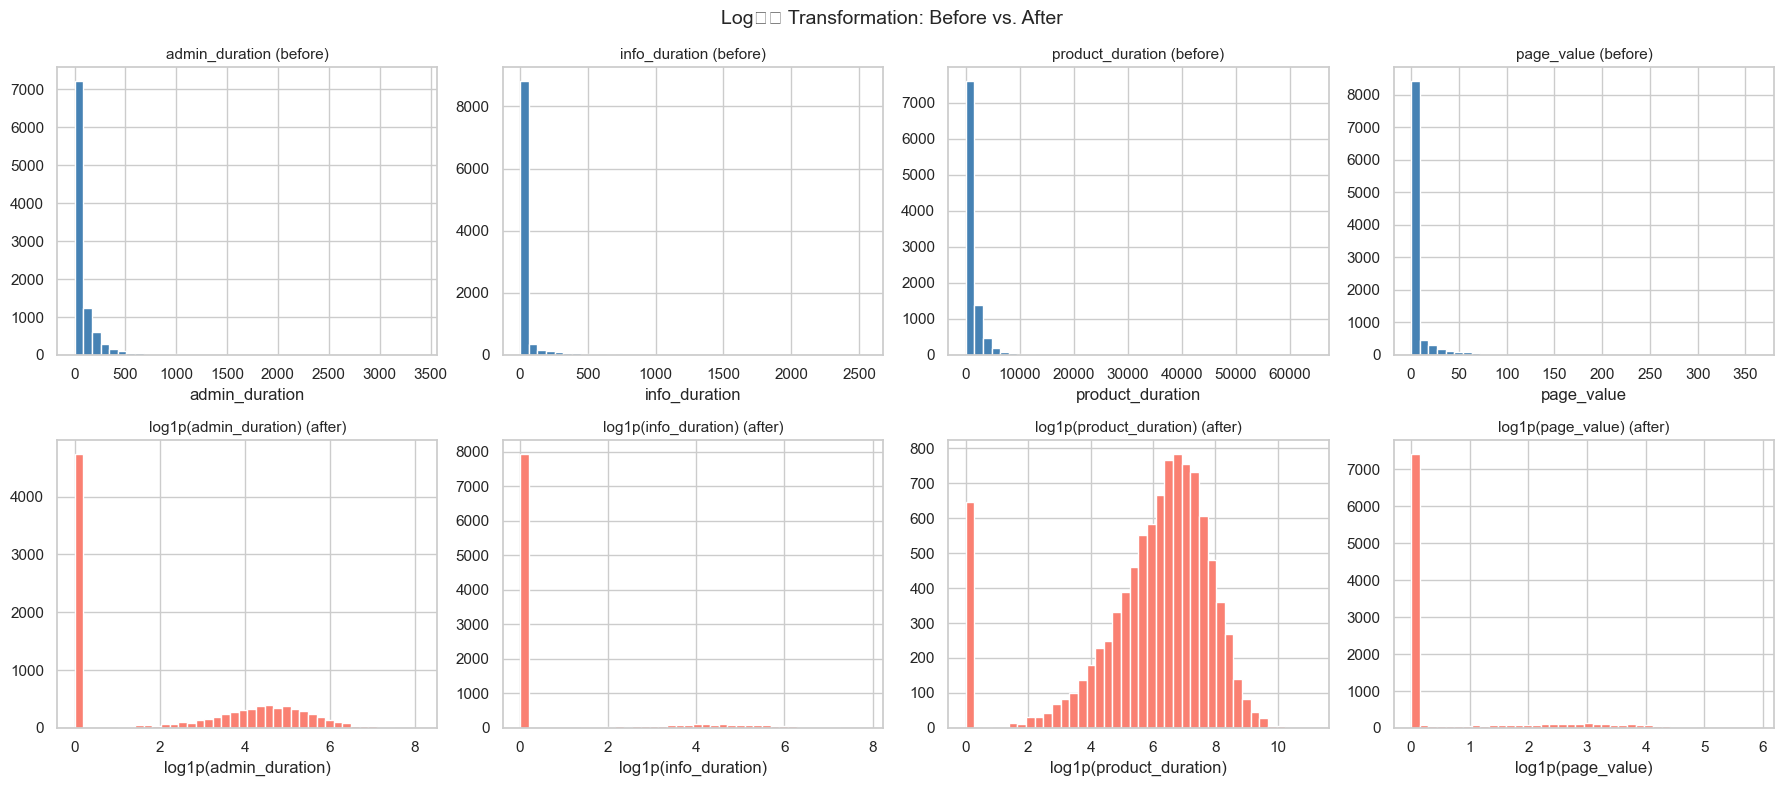

In [31]:
fig, axes = plt.subplots(2, len(LOG_COLS), figsize=(18, 8))

for i, col in enumerate(LOG_COLS):
    axes[0, i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'{col} (before)', fontsize=11)
    axes[0, i].set_xlabel(col)

# Apply log1p
for col in LOG_COLS:
    df_clean[col] = np.log1p(df_clean[col])

for i, col in enumerate(LOG_COLS):
    axes[1, i].hist(df_clean[col], bins=40, color='salmon', edgecolor='white')
    axes[1, i].set_title(f'log1p({col}) (after)', fontsize=11)
    axes[1, i].set_xlabel(f'log1p({col})')

plt.suptitle('Log₁ₚ Transformation: Before vs. After', fontsize=14)
plt.tight_layout()
plt.show()

### Step 7.6 — Categorical Encoding (One-Hot)

Nominal categorical columns are one-hot encoded. The encoder is **fit on the training set only** and reused on the test set to prevent leakage.

| Column | Unique values | OHE columns (drop_first) |
|---|---|---|
| `month` | 10 | 9 |
| `visitor_type` | 3 | 2 |
| `operating_system` | 8 | 7 |
| `browser` | 12 | 11 |
| `region` | 9 | 8 |
| `traffic_type` | 20 | 19 |

`is_weekend` is already binary (0/1) and needs no encoding.

In [32]:
try:
    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
except TypeError:
    ohe = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')

# Fit on training data only
ohe.fit(df_clean[CATEGORICAL_COLS].astype(str))

# Transform training data
ohe_array = ohe.transform(df_clean[CATEGORICAL_COLS].astype(str))
try:
    ohe_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_COLS))
except AttributeError:
    ohe_feature_names = list(ohe.get_feature_names(CATEGORICAL_COLS))

ohe_df = pd.DataFrame(ohe_array, columns=ohe_feature_names, index=df_clean.index)
df_processed = df_clean.drop(columns=CATEGORICAL_COLS).join(ohe_df)

print(f"Shape before OHE: {df_clean.shape}")
print(f"Shape after  OHE: {df_processed.shape}")
print(f"  Added {len(ohe_feature_names)} OHE columns for {len(CATEGORICAL_COLS)} categorical features")

Shape before OHE: (9864, 18)
Shape after  OHE: (9864, 68)
  Added 56 OHE columns for 6 categorical features


### Step 7.7 — Feature Scaling (MinMaxScaler)

Continuous numeric features are scaled to [0, 1] with `MinMaxScaler`. This is essential for distance-based and regularisation-based models. The scaler is **fit on training data only**.

Binary and OHE columns are already in {0, 1} and are not rescaled.

In [33]:
scaler = MinMaxScaler()
df_processed[SCALE_COLS] = scaler.fit_transform(df_processed[SCALE_COLS])

print(f"Scaled {len(SCALE_COLS)} features to [0, 1]:")
for col in SCALE_COLS:
    mn, mx = df_processed[col].min(), df_processed[col].max()
    print(f"  {col:<25} [{mn:.4f}, {mx:.4f}]")

Scaled 10 features to [0, 1]:
  num_admin_pages           [0.0000, 1.0000]
  num_info_pages            [0.0000, 1.0000]
  admin_duration            [0.0000, 1.0000]
  info_duration             [0.0000, 1.0000]
  product_duration          [0.0000, 1.0000]
  page_value                [0.0000, 1.0000]
  exit_rate                 [0.0000, 1.0000]
  abandonment_score         [0.0000, 1.0000]
  engagement_score          [0.0000, 1.0000]
  special_day_score         [0.0000, 1.0000]


### Step 7.8 — Final Training Set Summary

In [ ]:
y_train = df_processed['high_intent'].astype(int)
X_train = df_processed.drop(columns=['high_intent'])

print("=== Preprocessed Training Set ===")
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"Missing values: {X_train.isnull().sum().sum()}")
print(f"\nClass distribution:\n{y_train.value_counts().to_string()}")

# --- Collect all pipeline parameters for reuse on the test set ---
pipeline_params = {
    # Outlier clipping
    'engagement_clip_threshold'    : clip_threshold,
    # Month imputation (CatBoostClassifier)
    'catboost_month_imputer'       : catboost_month_imputer,
    'xgb_month_features'           : XGB_MONTH_FEATURES,
    'month_mode'                   : month_mode,
    # visitor_type imputation (XGBoostClassifier)
    'xgb_vt_imputer'               : xgb_vt_imputer,
    'xgb_vt_features'              : XGB_VT_FEATURES,
    'vt_le'                        : vt_le,
    'vt_mode'                      : vt_mode,
    # product_duration imputation (HistGradientBoostingRegressor)
    'hgb_product_duration_imputer' : hgb_product_duration_imputer,
    # page_value imputation (Conditional Median)
    'page_value_medians'           : page_value_medians,
    'page_value_global_median'     : page_value_global_median,
    'page_value_group_col'         : PAGE_VALUE_GROUP_COL,
    # Encoding / scaling
    'ohe'                          : ohe,
    'ohe_feature_names'            : ohe_feature_names,
    'scaler'                       : scaler,
    'scale_cols'                   : SCALE_COLS,
    'categorical_cols'             : CATEGORICAL_COLS,
    'log_cols'                     : LOG_COLS,
}
print("\nPipeline parameters stored in `pipeline_params`.")

In [35]:
X_train.to_csv('X_train_preprocessed.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=True)
print("Saved: X_train_preprocessed.csv")
print("Saved: y_train.csv")

Saved: X_train_preprocessed.csv
Saved: y_train.csv


## Section 8 — Test Set Preprocessing

We apply the **exact same** preprocessing pipeline to `shopper_test.csv` using parameters learned exclusively from the training set. The test set has no `high_intent` column, so none of its preprocessing steps condition on the target.

In [36]:
df_test = pd.read_csv(TEST_PATH)
print(f"Test set shape: {df_test.shape}")
missing_test = df_test.isnull().sum()
missing_test = missing_test[missing_test > 0]
print(f"\nMissing values in test set:\n{missing_test.to_string()}")
df_test.head()

Test set shape: (2466, 19)

Missing values in test set:
product_duration     95
bounce_rate         322
page_value          120
month               389
visitor_type        237


,num_admin_pages,admin_duration,num_info_pages,info_duration,num_product_pages,product_duration,bounce_rate,exit_rate,page_value,special_day_score,month,operating_system,browser,region,traffic_type,visitor_type,is_weekend,engagement_score,abandonment_score
0,6,179.750000,2,8.00,64,1876.333333,0.007246,0.014251,16.687115,0.0,Dec,2,5,9,2,NaN,0,29.015043,0.010749
1,0,0.000000,0,0.00,141,2886.523521,0.004317,0.018798,0.000000,0.8,May,2,2,4,3,NaN,0,59.587262,0.011557
2,0,0.000000,0,0.00,9,87.916667,0.000000,0.003175,0.000000,0.0,Nov,8,2,5,1,Returning_Visitor,1,5.395080,0.001587
3,6,229.000000,2,40.02,71,2576.432121,0.010270,0.045526,0.000000,0.0,NaN,1,1,2,1,Returning_Visitor,1,31.941820,0.027898
4,5,173.263213,0,0.00,49,1465.555338,NaN,0.023755,20.667246,0.0,NaN,3,2,3,1,Returning_Visitor,0,22.516269,0.023802


In [ ]:
def preprocess_test(df_input, params):
    # Apply the fitted preprocessing pipeline to a new dataset (no target column).
    df = df_input.copy()

    # Step 7.1: Drop bounce_rate
    if 'bounce_rate' in df.columns:
        df = df.drop(columns=['bounce_rate'])

    # Step 7.2: Clip engagement_score (use training 95th-pct threshold)
    df['engagement_score'] = df['engagement_score'].clip(
        upper=params['engagement_clip_threshold']
    )

    # Step 7.3a: product_duration zero-fill
    cond_zero = (df['num_product_pages'] == 0) & df['product_duration'].isna()
    df.loc[cond_zero, 'product_duration'] = 0.0

    # Step 7.3b: month — CatBoost imputation (fitted on training data)
    month_miss = df['month'].isna()
    if month_miss.sum() > 0:
        can_pred = df[month_miss].dropna(subset=params['xgb_month_features'])
        if len(can_pred) > 0:
            preds = params['catboost_month_imputer'].predict(
                can_pred[params['xgb_month_features']]
            ).reshape(-1)
            df.loc[can_pred.index, 'month'] = preds
        still_miss = df['month'].isna()
        if still_miss.sum() > 0:
            df.loc[still_miss, 'month'] = params['month_mode']

    # Step 7.3c: visitor_type — XGBoost imputation (fitted on training data)
    vt_miss = df['visitor_type'].isna()
    if vt_miss.sum() > 0:
        can_pred = df[vt_miss].dropna(subset=params['xgb_vt_features'])
        if len(can_pred) > 0:
            preds_encoded = params['xgb_vt_imputer'].predict(
                can_pred[params['xgb_vt_features']]
            )
            df.loc[can_pred.index, 'visitor_type'] = params['vt_le'].inverse_transform(preds_encoded)
        still_miss = df['visitor_type'].isna()
        if still_miss.sum() > 0:
            df.loc[still_miss, 'visitor_type'] = params['vt_mode']

    # Step 7.3d: product_duration — HistGradientBoosting (fitted on training data)
    pd_miss = df['product_duration'].isna()
    if pd_miss.sum() > 0:
        preds = np.expm1(params['hgb_product_duration_imputer'].predict(
            df.loc[pd_miss, ['engagement_score']]
        ))
        df.loc[pd_miss, 'product_duration'] = np.clip(preds, 0, None)

    # Step 7.3e: page_value — Conditional Median by traffic_type (from training)
    pv_miss = df['page_value'].isna()
    if pv_miss.sum() > 0:
        group_col = params['page_value_group_col']
        df.loc[pv_miss, 'page_value'] = (
            df.loc[pv_miss, group_col]
            .map(params['page_value_medians'])
            .fillna(params['page_value_global_median'])
            .values
        )

    # Step 7.4: Drop num_product_pages
    if 'num_product_pages' in df.columns:
        df = df.drop(columns=['num_product_pages'])

    # Step 7.5: Log1p transforms
    for col in params['log_cols']:
        df[col] = np.log1p(df[col])

    # Step 7.6: OHE using fitted encoder
    cat_array = params['ohe'].transform(df[params['categorical_cols']].astype(str))
    cat_df = pd.DataFrame(cat_array, columns=params['ohe_feature_names'], index=df.index)
    df = df.drop(columns=params['categorical_cols']).join(cat_df)

    # Ensure column alignment with training set
    for col in params['ohe_feature_names']:
        if col not in df.columns:
            df[col] = 0.0

    # Step 7.7: Scale using fitted scaler
    df[params['scale_cols']] = params['scaler'].transform(df[params['scale_cols']])

    return df

In [38]:
X_test = preprocess_test(df_test, pipeline_params)

# Align column order with training set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("=== Preprocessed Test Set ===")
print(f"Shape        : {X_test.shape}")
print(f"Missing values: {X_test.isnull().sum().sum()}")

missing_from_train = set(X_train.columns) - set(X_test.columns)
extra_in_test      = set(X_test.columns) - set(X_train.columns)
print(f"Columns in train but not test (filled with 0): {missing_from_train or 'none'}")
print(f"Columns in test but not train (dropped)       : {extra_in_test or 'none'}")

X_test.to_csv('X_test_preprocessed.csv', index=False)
print("\nSaved: X_test_preprocessed.csv")

=== Preprocessed Test Set ===
Shape        : (2466, 67)
Missing values: 0
Columns in train but not test (filled with 0): none
Columns in test but not train (dropped)       : none

Saved: X_test_preprocessed.csv


## Section 9 — Classification

We train and evaluate binary classifiers to predict `high_intent` (whether a session ends in a purchase).

**Starting point:** `X_train_preprocessed.csv` (9 864 × 67) and `X_test_preprocessed.csv` (2 466 × 67) produced in Section 8.

**Steps:**
1. Load preprocessed data
2. Define evaluation strategy (class imbalance handling)
3. Cross-validate candidate models and compare
4. Tune the best model with `GridSearchCV`
5. Evaluate with confusion matrix, ROC curve, and classification report
6. Inspect feature importance
7. Generate test-set predictions

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV,
)

### Step 9.1 — Load Preprocessed Data

We reload the CSV files saved at the end of Section 8. This allows Section 9 to be run independently.

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

X_train = pd.read_csv('X_train_preprocessed.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
X_test  = pd.read_csv('X_test_preprocessed.csv')

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nClass distribution (train):")
print(y_train.value_counts().to_string())
print(f"\nPositive class rate: {y_train.mean():.1%}  →  moderate imbalance")

### Step 9.2 — Evaluation Strategy

The target is moderately imbalanced (~26 % high-intent). **Accuracy alone is misleading** — a model that always predicts 0 scores ~74 % accuracy while being completely useless.

| Metric | Why |
|---|---|
| **F1 (positive class)** | Balances precision and recall on the minority class |
| **ROC-AUC** | Threshold-independent; measures ranking quality across all operating points |
| Accuracy | Reported for reference only; not used for model selection |

We use **Stratified 5-fold CV** so each fold preserves the original class ratio.

In [ ]:
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
SCORING = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

print("Evaluation setup:")
print(f"  CV strategy : StratifiedKFold (n_splits=5, shuffle=True)")
print(f"  Metrics     : {SCORING}")
print(f"  Model selection criterion: F1 on positive class")

### Step 9.3 — Candidate Models

We train and compare six models: a majority-class dummy baseline plus five real classifiers. All use default hyperparameters at this stage. Models with native `class_weight` support receive `'balanced'` to compensate for the imbalance. Model selection is by CV F1 on the positive class.

In [ ]:
candidate_models = {
    'Dummy (majority)'   : DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'KNN'                : KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1),
}

results = {}
print("Running 5-fold stratified cross-validation...\n")

for name, model in candidate_models.items():
    scores = cross_validate(model, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    results[name] = {m: scores[f'test_{m}'].mean()
                     for m in ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']}
    print(f"  {name:<25}  Acc={results[name]['accuracy']:.3f}  "
          f"F1={results[name]['f1']:.3f}  AUC={results[name]['roc_auc']:.3f}")

cv_results_df = pd.DataFrame(results).T.round(4)
print()
display(cv_results_df)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_plot = ['accuracy', 'f1', 'roc_auc']
titles       = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors       = ['#4C72B0', '#DD8452', '#55A868']
baseline_name = 'Dummy (majority)'

for ax, metric, title, color in zip(axes, metrics_plot, titles, colors):
    vals = cv_results_df[metric].sort_values(ascending=False)
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.axhline(cv_results_df.loc[baseline_name, metric],
               color='red', linestyle='--', linewidth=1, label='Dummy baseline')
    ax.legend(fontsize=8)

plt.suptitle('Cross-Validated Metrics — Candidate Models', fontsize=14)
plt.tight_layout()
plt.show()

best_model_name = cv_results_df.drop(index=baseline_name)['f1'].idxmax()
print(f"\nBest model by CV F1: {best_model_name}")
print(f"  F1      = {cv_results_df.loc[best_model_name, 'f1']:.4f}")
print(f"  ROC-AUC = {cv_results_df.loc[best_model_name, 'roc_auc']:.4f}")
print(f"  Acc     = {cv_results_df.loc[best_model_name, 'accuracy']:.4f}")

### Step 9.4 — Hyperparameter Tuning

We tune the best-performing model using `GridSearchCV` with stratified 5-fold CV, optimising for F1 score on the positive class.

In [ ]:
param_grids = {
    'Logistic Regression': {
        'C'           : [0.01, 0.1, 1, 10],
        'class_weight': ['balanced', None],
    },
    'Decision Tree': {
        'max_depth'       : [5, 10, 20, None],
        'min_samples_leaf': [1, 5, 10],
        'class_weight'    : ['balanced', None],
    },
    'Random Forest': {
        'n_estimators'    : [100, 300],
        'max_depth'       : [10, 20, None],
        'min_samples_leaf': [1, 5],
        'class_weight'    : ['balanced', None],
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5],
        'subsample'    : [0.8, 1.0],
    },
    'KNN': {
        'n_neighbors': [5, 11, 21, 31],
        'weights'    : ['uniform', 'distance'],
    },
}

base_clf = candidate_models[best_model_name]

if best_model_name in param_grids:
    grid_search = GridSearchCV(
        base_clf, param_grids[best_model_name],
        cv=CV, scoring='f1', n_jobs=-1, refit=True, verbose=0,
    )
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    print(f"Best hyperparameters for {best_model_name}:")
    for k, v in grid_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV F1 (tuned)  : {grid_search.best_score_:.4f}")
    print(f"CV F1   (default)   : {cv_results_df.loc[best_model_name, 'f1']:.4f}")
else:
    best_model = base_clf
    best_model.fit(X_train, y_train)
    print(f"No grid defined for {best_model_name} — using default params.")

### Step 9.5 — Final Model Evaluation

Using **cross-validated predictions** (`cross_val_predict`) we report the confusion matrix, classification report, and ROC curve — all on training data without touching the test set.

In [ ]:
y_cv_pred  = cross_val_predict(best_model, X_train, y_train, cv=CV, method='predict')
y_cv_proba = cross_val_predict(best_model, X_train, y_train, cv=CV, method='predict_proba')[:, 1]

print(f"=== {best_model_name} (tuned) — Cross-Validated Report ===\n")
print(classification_report(y_train, y_cv_pred,
                             target_names=['Low Intent (0)', 'High Intent (1)']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_cv_pred,
    display_labels=['Low Intent', 'High Intent'],
    cmap='Blues', ax=axes[0],
)
axes[0].set_title(f'Confusion Matrix — {best_model_name} (CV)', fontsize=12)

fpr, tpr, _ = roc_curve(y_train, y_cv_proba)
auc_val     = roc_auc_score(y_train, y_cv_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Cross-Validated)', fontsize=12)
axes[1].legend()
plt.tight_layout()
plt.show()

### Step 9.6 — Feature Importance

We inspect which features drive the model's predictions most strongly.

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    feat_imp = (
        pd.Series(best_model.feature_importances_, index=X_train.columns)
        .sort_values(ascending=False)
    )
    top_n = 20
    fig, ax = plt.subplots(figsize=(12, 6))
    feat_imp.head(top_n).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Top {top_n} Feature Importances — {best_model_name}', fontsize=13)
    ax.set_ylabel('Importance')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"Top 10 features:\n{feat_imp.head(10).round(4).to_string()}")

elif hasattr(best_model, 'coef_'):
    coefs = (
        pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)
        .sort_values(ascending=False)
    )
    top_n = 20
    fig, ax = plt.subplots(figsize=(12, 6))
    coefs.head(top_n).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Top {top_n} |Coefficients| — {best_model_name}', fontsize=13)
    ax.set_ylabel('|Coefficient|')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print(f"Top 10 features:\n{coefs.head(10).round(4).to_string()}")

else:
    print(f"{best_model_name} does not expose feature importances or coefficients directly.")

### Step 9.7 — Precision–Recall Curve

For imbalanced datasets the PR curve is often more informative than ROC. We plot it alongside the no-skill baseline (a horizontal line at the positive class rate).

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_train, y_cv_proba)
ap_score = average_precision_score(y_train, y_cv_proba)
no_skill  = y_train.mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall_vals, precision_vals, color='steelblue', lw=2,
        label=f'PR curve (AP = {ap_score:.3f})')
ax.axhline(no_skill, color='red', linestyle='--', lw=1,
           label=f'No-skill baseline (P = {no_skill:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve (Cross-Validated)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Average Precision (AP): {ap_score:.4f}")

### Step 9.8 — Test Set Predictions

We apply the tuned model to the held-out test set and save predicted labels and probabilities to `test_predictions.csv`.

In [ ]:
best_model.fit(X_train, y_train)   # refit on full training set

y_pred_test  = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

predictions_df = pd.DataFrame({
    'predicted_high_intent': y_pred_test,
    'proba_high_intent'    : y_proba_test.round(4),
})
predictions_df.to_csv('test_predictions.csv', index=False)

print(f"Saved: test_predictions.csv  ({len(predictions_df)} rows)")
print(f"\nPredicted class distribution:")
print(predictions_df['predicted_high_intent'].value_counts().to_string())
print(f"\nMean predicted probability: {y_proba_test.mean():.3f}")
display(predictions_df.head(10))